# SOLA Failure with Bessel-Sobolev Smoothness

This notebook follows the original `sola_failure.ipynb` structure, but the hidden counterexample is constructed with `intervalinf` Bessel-Sobolev operators instead of hand-built smoothing matrices.

The story is:

1. Set up a normal-looking inverse problem.
2. Solve it with SOLA and show that the estimates, error bars, and resolving kernels look reasonable.
3. Choose alternative target property values outside every SOLA error band.
4. Use a Bessel-Sobolev smoothness prior to find a smooth model with those properties and the same data.
5. Reveal that this alternative model could have been the true model all along, while SOLA would have returned exactly the same estimate because the data are the same.


In [65]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import lstsq

from intervalinf import (
    BoundaryConditions,
    Function,
    IntegrationConfig,
    IntervalDomain,
    Lebesgue,
)
from intervalinf.operators import (
    BesselSobolev,
    BesselSobolevInverse,
    Laplacian,
    SOLAOperator,
)
from intervalinf.providers import BumpFunctionProvider, NormalModesProvider
from pygeoinf import (
    CholeskySolver,
    EuclideanSpace,
    GaussianMeasure,
    LinearBayesianInversion,
    LinearForwardProblem,
    LinearOperator,
    LUSolver,
)

plt.style.use("seaborn-v0_8-whitegrid")
rng = np.random.default_rng(42)


## 1. Problem Setup

The model space is deliberately basis-free: `Lebesgue(0, domain, basis=None)`. The data and target maps are continuous `SOLAOperator` integrations against interval functions.


In [66]:
domain = IntervalDomain(0.0, 1.0)
integration = IntegrationConfig(method="simpson", n_points=500)

M = Lebesgue(0, domain, basis=None)
n_data = 60
n_property = 10
D = EuclideanSpace(n_data)
P = EuclideanSpace(n_property)

width = 0.20
centers = np.linspace(domain.a + width / 2.0, domain.b - width / 2.0, n_property)
x = np.linspace(domain.a, domain.b, 900)

normal_modes = NormalModesProvider(
    M,
    n_modes_range=(1, 8),
    coeff_range=(-4.0, 4.0),
    gaussian_width_percent_range=(6.0, 20.0),
    freq_range=(0.5, 14.0),
    random_state=2,
)
G = SOLAOperator(M, D, kernels=normal_modes, cache_kernels=True, integration_config=integration)

targets = BumpFunctionProvider(M, centers=centers, default_width=width)
T = SOLAOperator(M, P, kernels=targets, cache_kernels=True, integration_config=integration)

print(f"Model space basis dimension: {M.dim} (basis-free)")
print(f"Data dimension: {D.dim}")
print(f"Property dimension: {P.dim}")


Model space basis dimension: 0 (basis-free)
Data dimension: 60
Property dimension: 10


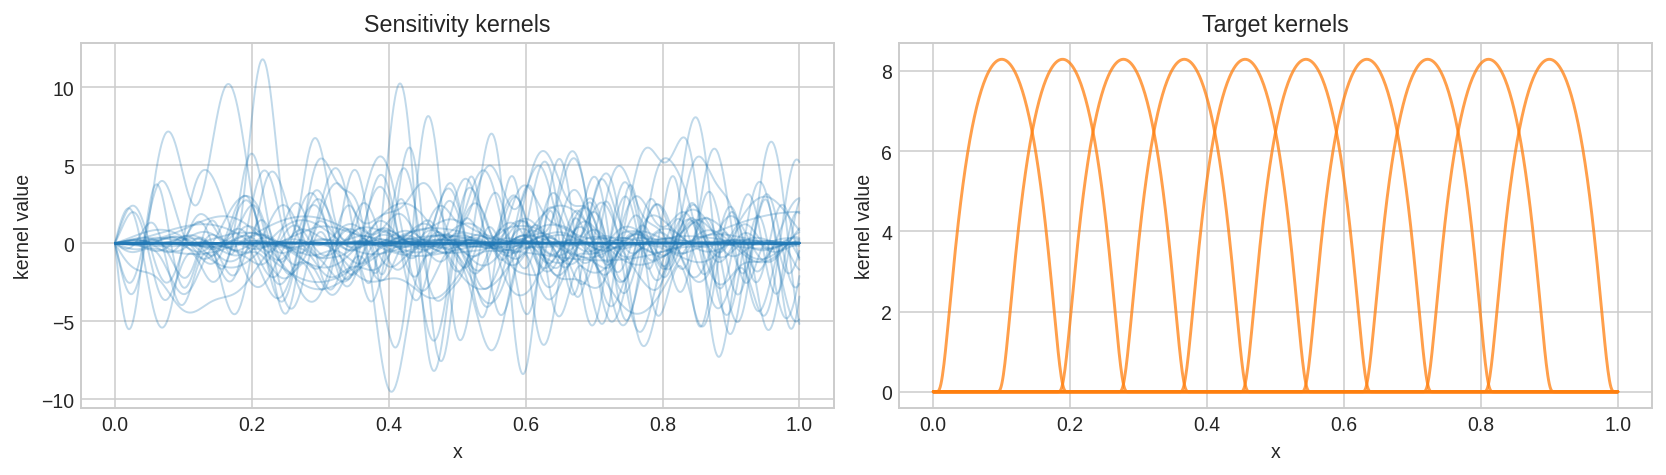

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), dpi=140)

for i in range(n_data):
    axes[0].plot(x, G.get_kernel(i)(x), color="tab:blue", alpha=0.28, lw=1.0)
axes[0].set_title("Sensitivity kernels")
axes[0].set_xlabel("x")
axes[0].set_ylabel("kernel value")

for i in range(n_property):
    axes[1].plot(x, T.get_kernel(i)(x), color="tab:orange", alpha=0.75, lw=1.5)
axes[1].set_title("Target kernels")
axes[1].set_xlabel("x")
axes[1].set_ylabel("kernel value")

fig.tight_layout()
plt.show()


## 2. Bessel-Sobolev Smoothness

The counterexample model will be chosen as the smoothest model satisfying the hidden constraints, where smoothest means small Bessel-Sobolev precision norm:

$$
C_M = \tau^2 (k^2 I - \Delta)^{-s/2},
\qquad
C_M^{-1} = \tau^{-2}(k^2 I - \Delta)^{s/2}.
$$

`smooth_dofs` is only the spectral truncation used by the Bessel operators. It is not a basis for the model space.


In [68]:
smooth_dofs = 80
bessel_k = 1.0
sobolev_order = 4.0
prior_scale = 10.0

laplacian = Laplacian(
    M,
    BoundaryConditions.neumann(),
    method="spectral",
    dofs=smooth_dofs,
    n_samples=512,
    integration_config=integration,
)
prior_precision = BesselSobolev(
    M,
    M,
    k=bessel_k,
    s=sobolev_order,
    L=laplacian,
    dofs=smooth_dofs,
    n_samples=512,
    integration_config=integration,
)
prior_covariance = BesselSobolevInverse(
    M,
    M,
    k=bessel_k,
    s=sobolev_order,
    L=laplacian,
    dofs=smooth_dofs,
    n_samples=512,
    integration_config=integration,
)

smooth_prior = GaussianMeasure(
    covariance=(prior_scale**2) * prior_covariance,
    inverse_covariance=(prior_scale**-2) * prior_precision,
)

print("Prior covariance: tau^2 * BesselSobolevInverse")
print("Prior precision: tau^-2 * BesselSobolev")


Prior covariance: tau^2 * BesselSobolevInverse
Prior precision: tau^-2 * BesselSobolev


### What the Norm Rewards and Penalizes

The precision eigenvalue is the penalty attached to each Laplacian eigenfunction in the Bessel-Sobolev norm. Low-frequency modes are cheap; high-frequency modes are expensive.


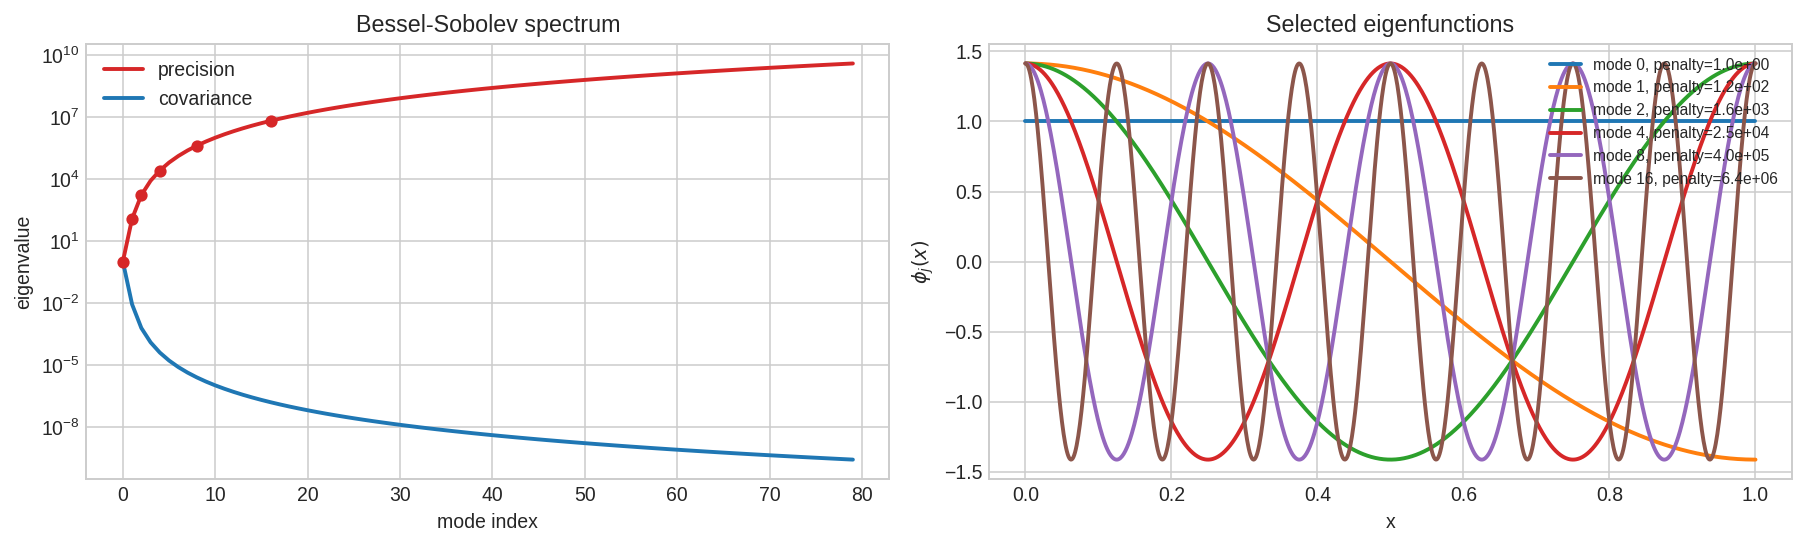

In [69]:
mode_indices = np.arange(smooth_dofs)
precision_eigenvalues = np.array([prior_precision.get_eigenvalue(i) for i in mode_indices])
covariance_eigenvalues = np.array([prior_covariance.get_eigenvalue(i) for i in mode_indices])
selected_modes = [0, 1, 2, 4, 8, 16]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), dpi=140)

axes[0].semilogy(mode_indices, precision_eigenvalues, color="tab:red", lw=2.0, label="precision")
axes[0].semilogy(mode_indices, covariance_eigenvalues, color="tab:blue", lw=2.0, label="covariance")
axes[0].scatter(selected_modes, precision_eigenvalues[selected_modes], color="tab:red", s=28, zorder=3)
axes[0].set_title("Bessel-Sobolev spectrum")
axes[0].set_xlabel("mode index")
axes[0].set_ylabel("eigenvalue")
axes[0].legend()

for mode in selected_modes:
    phi = prior_precision.get_eigenfunction(mode)
    axes[1].plot(x, phi(x), lw=2.0, label=f"mode {mode}, penalty={precision_eigenvalues[mode]:.1e}")
axes[1].set_title("Selected eigenfunctions")
axes[1].set_xlabel("x")
axes[1].set_ylabel(r"$\phi_j(x)$")
axes[1].legend(fontsize=8, loc="upper right")

fig.tight_layout()
plt.show()


## 3. A Normal True Model and Data

First create an ordinary smooth true model. This is the problem the analyst thinks they are solving.


In [70]:
m_normal = Function(
    M,
    evaluate_callable=lambda x: (
        np.exp(-((x - domain.center) / 0.28) ** 2) * np.sin(4.0 * np.pi * x)
        + 0.7 * (x - 0.5)
    ),
)

d_bar = G(m_normal)
p_normal = T(m_normal)

noise_fraction = 0.01
noise_std = noise_fraction * np.linalg.norm(d_bar) / np.sqrt(n_data)
d_tilde = d_bar + rng.normal(0.0, noise_std, size=n_data)

data_noise = GaussianMeasure.from_standard_deviation(D, noise_std)
data_measure = data_noise.affine_mapping(translation=d_tilde)

print(f"Normal model L2 norm: {M.norm(m_normal):.3f}")
print(f"Data noise standard deviation: {noise_std:.3e}")
print(f"Normal properties: min={p_normal.min():.3f}, max={p_normal.max():.3f}")


Normal model L2 norm: 0.479
Data noise standard deviation: 1.586e-03
Normal properties: min=-0.790, max=0.790


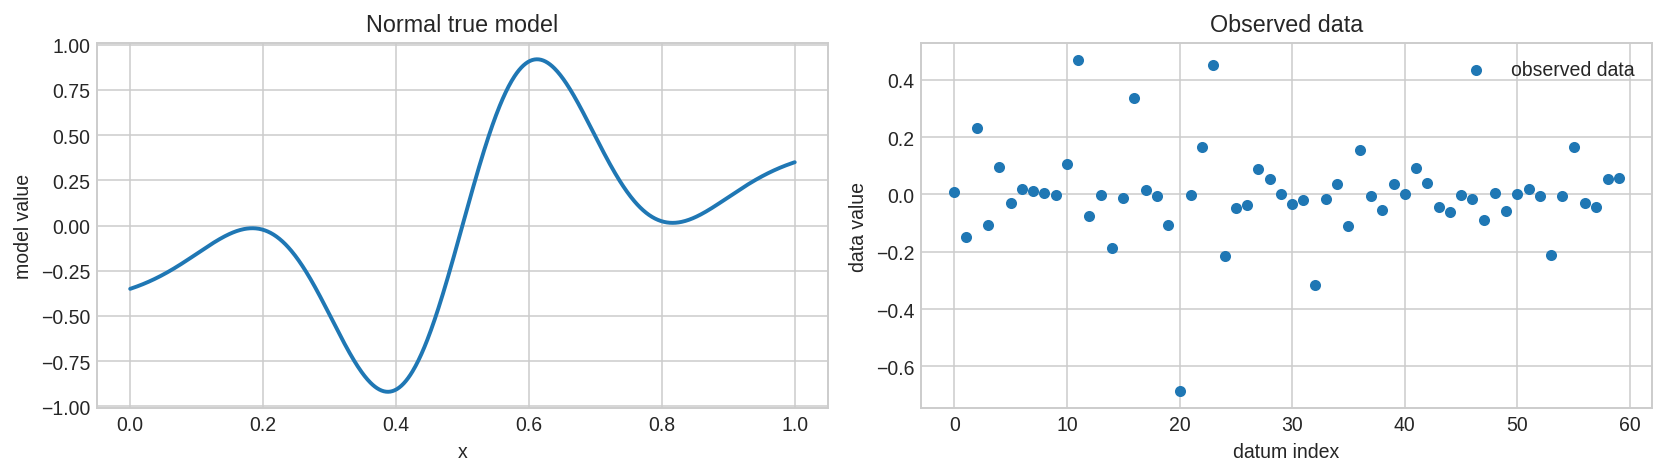

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), dpi=140)
axes[0].plot(x, m_normal(x), color="tab:blue", lw=2.0)
axes[0].set_title("Normal true model")
axes[0].set_xlabel("x")
axes[0].set_ylabel("model value")

idx = np.arange(n_data)
axes[1].scatter(idx, d_tilde, s=22, color="tab:blue", label="observed data")
axes[1].errorbar(idx, d_tilde, yerr=noise_std, fmt="none", color="tab:blue", alpha=0.45, capsize=2)
axes[1].set_title("Observed data")
axes[1].set_xlabel("datum index")
axes[1].set_ylabel("data value")
axes[1].legend()

fig.tight_layout()
plt.show()


## 4. SOLA Analysis of the Normal Problem

The analyst computes the regularized SOLA property estimator from the data. Nothing suspicious appears: the normal true properties are inside the error bands, and the resolving kernels are close to the requested targets.


In [72]:
sola_solver = CholeskySolver(galerkin=False, parallel=False)
W_inv = sola_solver((G @ G.adjoint) + data_noise.covariance)
G_inverse = G.adjoint @ W_inv
X = T @ G_inverse

# Unimodular correction: a constant model should map to constant target averages.
one = Function(M, evaluate_callable=lambda z: np.ones_like(np.asarray(z, dtype=float)))
v = G(one)
w = np.ones(n_property)
u = W_inv(v)
beta = D.inner_product(v, u)
correction = LinearOperator.from_matrix(D, P, np.outer((X(v) - w) / beta, u))
X_unimodular = X - correction

property_measure = data_measure.affine_mapping(operator=X_unimodular)
p_sola = property_measure.expectation
property_covariance = property_measure.covariance.matrix(dense=True)
p_std = np.sqrt(np.maximum(np.diag(property_covariance), 0.0))

normal_within_2std = int(np.sum(np.abs(p_sola - p_normal) <= 2.0 * p_std))
print(f"Unimodularity max error: {np.max(np.abs(X_unimodular(v) - w)):.2e}")
print(f"Normal true properties inside +/-2 std: {normal_within_2std}/{n_property}")
print(f"Mean normal error / posterior std: {np.mean(np.abs(p_sola - p_normal) / p_std):.2f}")


Unimodularity max error: 0.00e+00
Normal true properties inside +/-2 std: 10/10
Mean normal error / posterior std: 0.63


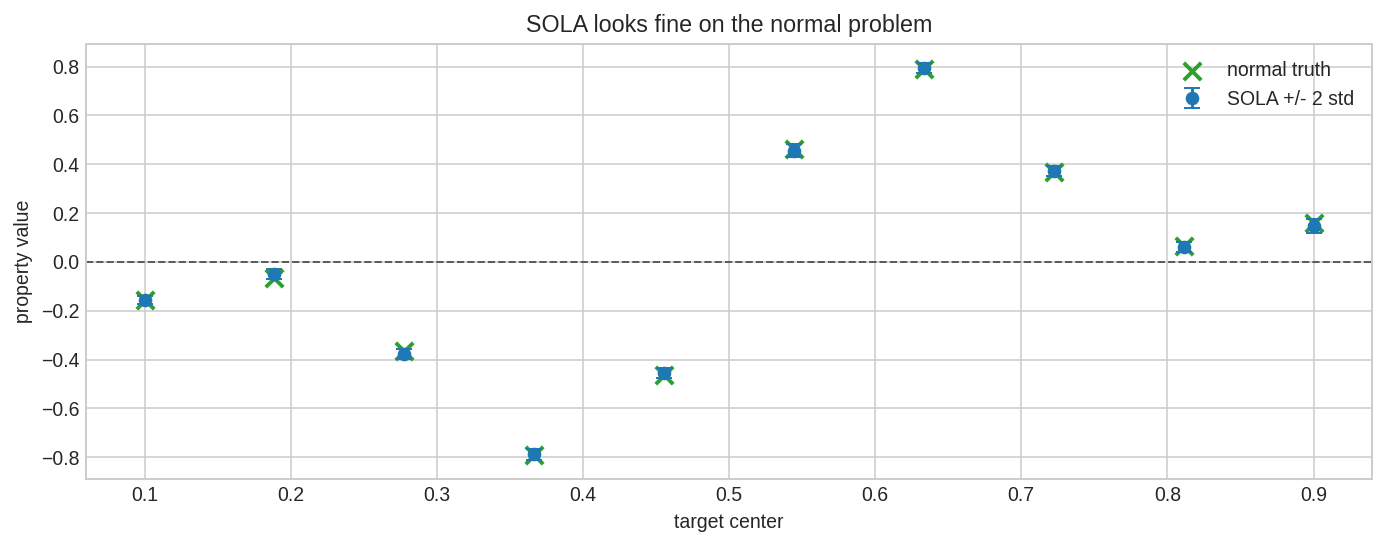

In [73]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=140)
ax.errorbar(centers, p_sola, yerr=2.0 * p_std, fmt="o", color="tab:blue", capsize=4, label="SOLA +/- 2 std")
ax.scatter(centers, p_normal, color="tab:green", marker="x", s=80, linewidths=2.0, label="normal truth")
ax.axhline(0.0, color="0.35", lw=1.0, ls="--")
ax.set_title("SOLA looks fine on the normal problem")
ax.set_xlabel("target center")
ax.set_ylabel("property value")
ax.legend()
fig.tight_layout()
plt.show()


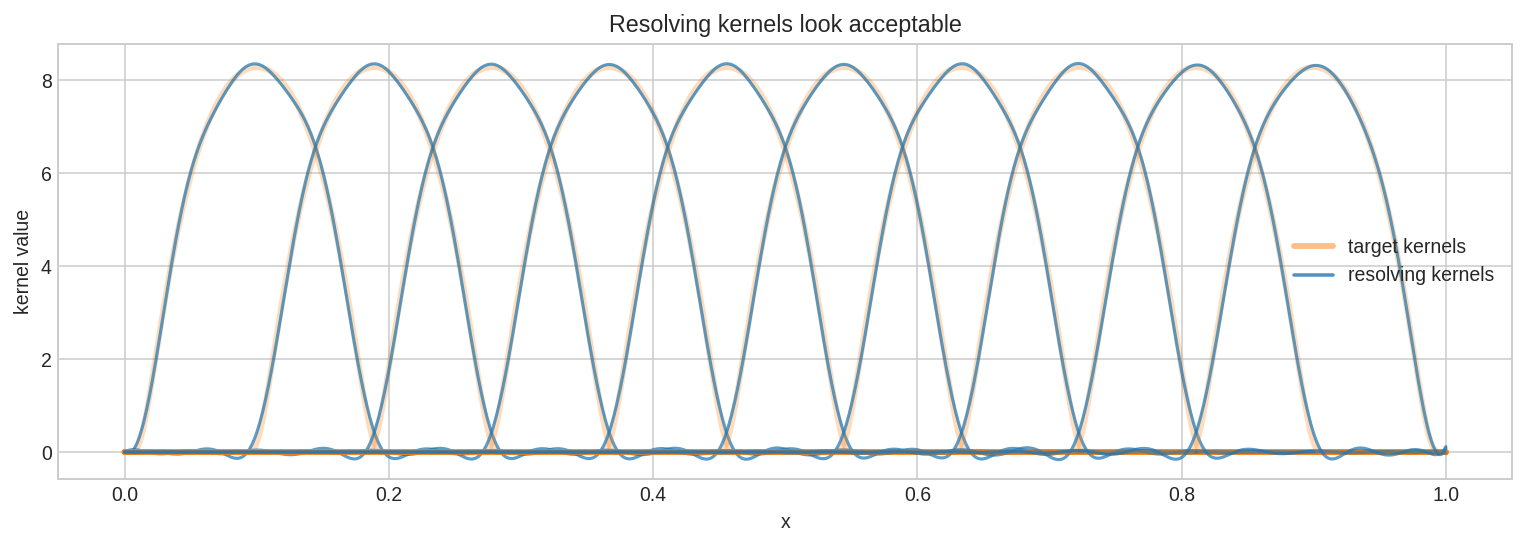

Mean resolving-kernel relative misfit: 1.8%
Max resolving-kernel relative misfit: 1.9%


In [74]:
A_adjoint = (X_unimodular @ G).adjoint
basis_direction = np.zeros(n_property)
resolving_misfits = np.zeros(n_property)
resolving_kernels = []

for i in range(n_property):
    basis_direction[i] = 1.0
    resolving_kernel = A_adjoint(basis_direction)
    target_kernel = T.get_kernel(i)
    resolving_kernels.append(resolving_kernel)
    resolving_misfits[i] = M.norm(resolving_kernel - target_kernel) / M.norm(target_kernel)
    basis_direction[i] = 0.0

fig, ax = plt.subplots(figsize=(11, 4), dpi=140)
for i in range(n_property):
    ax.plot(x, T.get_kernel(i)(x), color="tab:orange", alpha=0.28, lw=3.0)
    ax.plot(x, resolving_kernels[i](x), color="tab:blue", alpha=0.72, lw=1.6)
ax.plot([], [], color="tab:orange", lw=3.0, alpha=0.5, label="target kernels")
ax.plot([], [], color="tab:blue", lw=1.8, alpha=0.8, label="resolving kernels")
ax.set_title("Resolving kernels look acceptable")
ax.set_xlabel("x")
ax.set_ylabel("kernel value")
ax.legend()
fig.tight_layout()
plt.show()

print(f"Mean resolving-kernel relative misfit: {100.0 * resolving_misfits.mean():.1f}%")
print(f"Max resolving-kernel relative misfit: {100.0 * resolving_misfits.max():.1f}%")


## 5. Define Alternative Target Properties

Now define a different set of target property values. They are chosen just outside every `+/-2 std` SOLA band. At this point these are only hypothetical property values, not yet a model.


In [75]:
target_offset_factor = 20
property_direction = np.where(p_sola >= np.mean(p_sola), -1.0, 1.0)
p_alternative_target = p_sola + target_offset_factor * p_std * property_direction

outside_requested = np.abs(p_alternative_target - p_sola) > 2.0 * p_std
print(f"Requested alternative properties outside +/-2 std: {np.sum(outside_requested)}/{n_property}")
print(f"Smallest requested margin beyond 2 std: {np.min((np.abs(p_alternative_target - p_sola) - 2.0 * p_std) / p_std):.2f} std")


Requested alternative properties outside +/-2 std: 10/10
Smallest requested margin beyond 2 std: 18.00 std


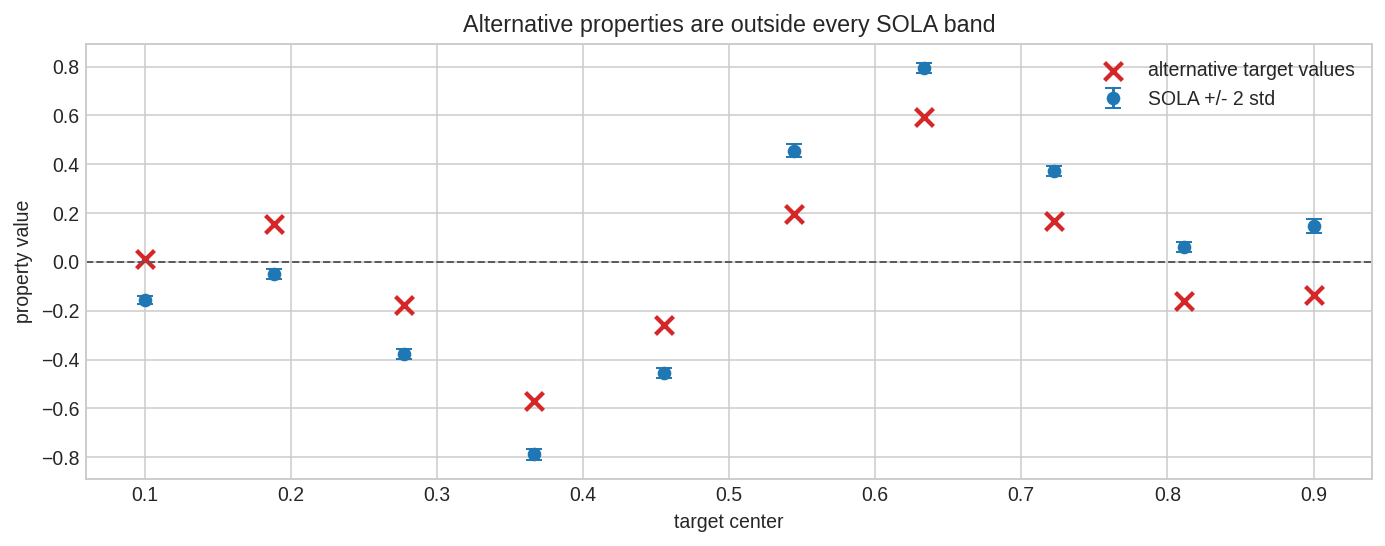

In [76]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=140)
ax.errorbar(centers, p_sola, yerr=2.0 * p_std, fmt="o", color="tab:blue", capsize=4, label="SOLA +/- 2 std")
ax.scatter(centers, p_alternative_target, color="tab:red", marker="x", s=85, linewidths=2.2, label="alternative target values")
ax.axhline(0.0, color="0.35", lw=1.0, ls="--")
ax.set_title("Alternative properties are outside every SOLA band")
ax.set_xlabel("target center")
ax.set_ylabel("property value")
ax.legend()
fig.tight_layout()
plt.show()


## 6. Find a Smooth Model with the Same Data and Alternative Properties

This is the hidden step. We solve for a perturbation `h` in the Bessel-Sobolev covariance-factor range such that

1. `G(h) = 0`, so `m_normal + h` gives the same noiseless data, and
2. `T(h) = p_alternative_target - T(m_normal)`, so the new model has the alternative properties.

The unknowns are the whitened Bessel coefficients. The columns are still built by `intervalinf`/`pygeoinf` operators: a Bessel covariance-factor mode is mapped through `G` and `T`, then a small dense least-squares solve finds the minimum coefficient-norm perturbation satisfying the constraints. This avoids the ill-conditioned inverse of `[G; T] C_M [G; T]^*` for far-away property targets.


In [77]:
bessel_factor = prior_scale * prior_covariance.spectral_factor()
coefficient_space = bessel_factor.domain

constraint_matrix = np.zeros((n_data + n_property, coefficient_space.dim))
for j in range(coefficient_space.dim):
    mode_model = bessel_factor(coefficient_space.basis_vector(j))
    constraint_matrix[:n_data, j] = G(mode_model)
    constraint_matrix[n_data:, j] = T(mode_model)

property_delta = p_alternative_target - p_normal
constraint_rhs = np.concatenate([np.zeros(n_data), property_delta])

bessel_coefficients, residuals, constraint_rank, singular_values = lstsq(
    constraint_matrix,
    constraint_rhs,
    lapack_driver="gelsd",
)

h_alternative = bessel_factor(bessel_coefficients)
m_alternative = M.add(m_normal, h_alternative)

p_alternative_true = T(m_alternative)
data_fit_relative = np.linalg.norm(G(m_alternative) - d_bar) / np.linalg.norm(d_bar)
property_fit_relative = np.linalg.norm(p_alternative_true - p_alternative_target) / np.linalg.norm(p_alternative_target)
model_difference_relative = M.norm(h_alternative) / M.norm(m_normal)
bessel_coefficient_norm = np.linalg.norm(bessel_coefficients)

same_sola_from_same_data = X_unimodular(d_tilde)
sola_reuse_error = np.linalg.norm(same_sola_from_same_data - p_sola)

print("Alternative model verification")
print(f"  constraint matrix rank: {constraint_rank}/{n_data + n_property}")
print(f"  relative data-fit error: {data_fit_relative:.3e}")
print(f"  relative property-target error: {property_fit_relative:.3e}")
print(f"  ||m_alt - m_normal|| / ||m_normal||: {model_difference_relative:.2f}")
print(f"  Bessel coefficient norm of perturbation: {bessel_coefficient_norm:.3e}")
print(f"  reusing the same data changes SOLA by: {sola_reuse_error:.3e}")


Alternative model verification
  constraint matrix rank: 66/70
  relative data-fit error: 3.027e-09
  relative property-target error: 1.806e-09
  ||m_alt - m_normal|| / ||m_normal||: 82.87
  Bessel coefficient norm of perturbation: 1.642e+05
  reusing the same data changes SOLA by: 0.000e+00


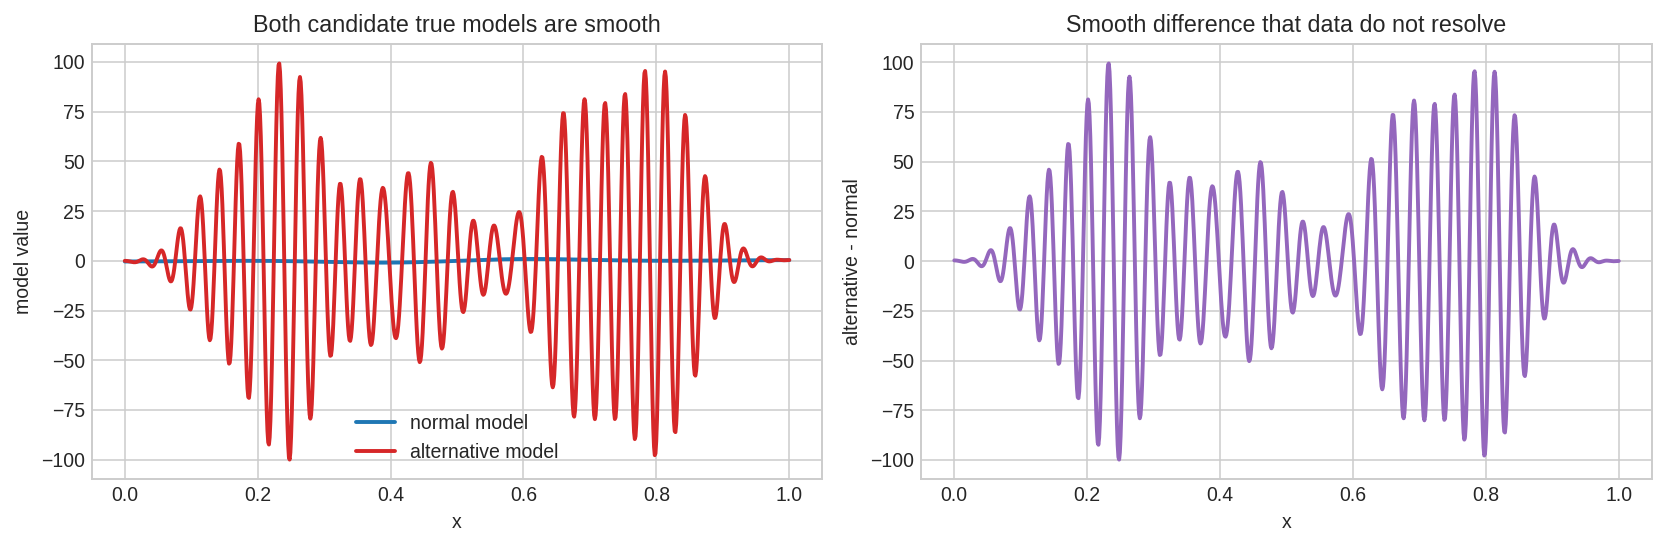

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=140)

axes[0].plot(x, m_normal(x), color="tab:blue", lw=2.0, label="normal model")
axes[0].plot(x, m_alternative(x), color="tab:red", lw=2.0, label="alternative model")
axes[0].set_title("Both candidate true models are smooth")
axes[0].set_xlabel("x")
axes[0].set_ylabel("model value")
axes[0].legend()

axes[1].plot(x, m_alternative(x) - m_normal(x), color="tab:purple", lw=2.0)
axes[1].set_title("Smooth difference that data do not resolve")
axes[1].set_xlabel("x")
axes[1].set_ylabel("alternative - normal")

fig.tight_layout()
plt.show()


## 7. Secretly Swap the True Model

Now pretend the alternative model was the true model all along. The data are the same, so SOLA returns the same estimate. The true properties, however, are outside every reported SOLA error band.


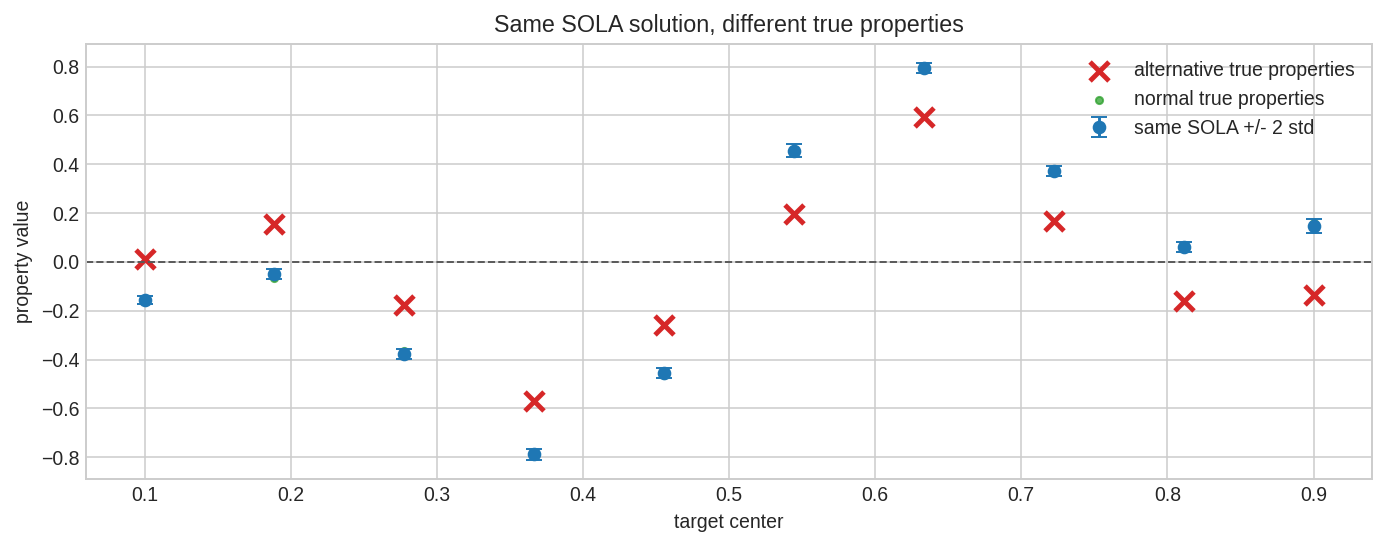

Alternative true properties outside +/-2 std: 10/10
Mean alternative error / posterior std: 20.00


In [79]:
alternative_errors = np.abs(p_sola - p_alternative_true)
alternative_outside = alternative_errors > 2.0 * p_std

fig, ax = plt.subplots(figsize=(10, 4), dpi=140)
ax.errorbar(centers, p_sola, yerr=2.0 * p_std, fmt="o", color="tab:blue", capsize=4, label="same SOLA +/- 2 std")
ax.scatter(centers, p_alternative_true, color="tab:red", marker="x", s=95, linewidths=2.5, label="alternative true properties")
ax.scatter(centers, p_normal, color="tab:green", marker=".", s=55, alpha=0.75, label="normal true properties")
ax.axhline(0.0, color="0.35", lw=1.0, ls="--")
ax.set_title("Same SOLA solution, different true properties")
ax.set_xlabel("target center")
ax.set_ylabel("property value")
ax.legend()
fig.tight_layout()
plt.show()

print(f"Alternative true properties outside +/-2 std: {np.sum(alternative_outside)}/{n_property}")
print(f"Mean alternative error / posterior std: {np.mean(alternative_errors / p_std):.2f}")


## 8. Regression Checks

The checks below pin the intended counterexample: the normal problem looks fine, the alternative target properties are all outside the SOLA bands, the alternative model fits the same data, and the same data produce the same SOLA estimate.


In [80]:
requested_margin = np.min((np.abs(p_alternative_target - p_sola) - 2.0 * p_std) / p_std)
true_margin = np.min((np.abs(p_alternative_true - p_sola) - 2.0 * p_std) / p_std)

print("Regression diagnostics")
print(f"  normal properties inside +/-2 std: {normal_within_2std}/{n_property}")
print(f"  requested alternative margin: {requested_margin:.3f} std")
print(f"  true alternative margin: {true_margin:.3f} std")
print(f"  relative data-fit error: {data_fit_relative:.3e}")
print(f"  relative property-target error: {property_fit_relative:.3e}")
print(f"  same-data SOLA reuse error: {sola_reuse_error:.3e}")

assert normal_within_2std == n_property
assert np.all(outside_requested)
assert np.all(alternative_outside)
assert data_fit_relative < 1.0e-6
assert property_fit_relative < 1.0e-6
assert sola_reuse_error < 1.0e-12


Regression diagnostics
  normal properties inside +/-2 std: 10/10
  requested alternative margin: 18.000 std
  true alternative margin: 18.000 std
  relative data-fit error: 3.027e-09
  relative property-target error: 1.806e-09
  same-data SOLA reuse error: 0.000e+00


## Conclusion

The normal SOLA workflow gives plausible estimates, uncertainty bars, and resolving kernels. But the alternative smooth model gives essentially the same data and therefore exactly the same SOLA estimate, while its true properties sit outside every reported error band.

The failure is not that SOLA made a numerical mistake. The failure is that the data and resolving kernels do not rule out all smooth property-relevant alternatives.
